In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from cuda_cqed.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

## Fast Res Driving

In [3]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wb', 5.35e9*2*pi)
sim.add_param('wc', 7.275e9*2*pi, is_excitation=True)
sim.add_param('sqrtkb', np.sqrt(1e6 * 2 * np.pi))
sim.add_param('sqrtkc', np.sqrt(2e6 * 2 * np.pi))
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 10e6 * 2 * np.pi)

sim.add_param('amplG', 0.1)  # 18 - gain
sim.add_param('amplC2', 0.3)  # 12 - c2
sim.add_param('wG', 10.7e9 * 2 * np.pi)  # 19
sim.add_param('wC2', -1.925e9 * 2 * np.pi)  # 13
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startG', 20e-9)  # 21
sim.add_param('stopG', 100e-9)  # 22
sim.add_param('startC2', 20e-9)  # 15
sim.add_param('stopC2', 100e-9)  # 16
sim.add_param('phaseG', 0)  # 23
sim.add_param('phaseC2', 0)  # 17

Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')
C2pulse = sim.make_pulse('wC2', 'amplC2', 'phaseC2', 'startC2', 'stopC2', 'rampC2')

sim.add_EOM('s1', Gpulse)
sim.add_EOM('s2', C2pulse)

sim.add_EOM('b', '-1j*wb*b - 1j*gbc*c*s2 - (sqrtkb**2/2)*b + 1j*g3*conjugate(b)*s1 - 1j*b*g4*abs(b)**2', IC_str='1')
sim.add_EOM('c', '-1j*wc*c - 1j*gbc*b*conjugate(s2) - (sqrtkc**2/2)*c')
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=20, num_cycles=1000, d_factor=10)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


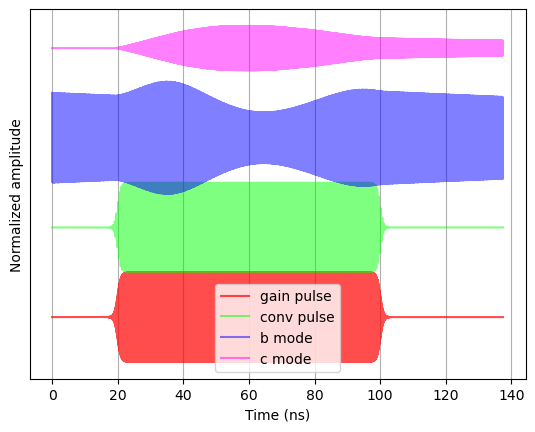

In [4]:
x, t = sim.quick_trace()

scale = 1

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='gain pulse')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='conv pulse')
plt.plot(t*1e9, x[4,:]/scale+4,color=(0,0,1,0.5),label='b mode')
plt.plot(t*1e9, x[6,:]/scale+6,color=(1,0,1,0.5),label='c mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.yticks([])
plt.grid()
plt.show()

In [79]:
sqrtkb = sim.param_dict_nosweep['sqrtkb']
sqrtkc = sim.param_dict_nosweep['sqrtkc']

aout_I = x[0,:] + sqrtka*x[12,:]
aout_Q = x[1,:] + sqrtka*x[13,:]

bout_I = x[2,:] + sqrtkb*x[14,:]
bout_Q = x[3,:] + sqrtkb*x[15,:]

cout_I = x[4,:] + sqrtkc*x[16,:]
cout_Q = x[5,:] + sqrtkc*x[17,:]

# plt.plot(t*1e9, (aout_I+1j*aout_Q)*np.exp(1j*6.4e9*2*pi*t)/np.max(aout_I))
# plt.plot(t*1e9, (aout_I+1j*aout_Q)*np.exp(1j*6.4e9*2*pi*t+1j*np.pi/2)/np.max(aout_I))

plt.plot(t*1e9, (bout_I+1j*bout_Q)*np.exp(1j*5.35e9*2*pi*t))
plt.plot(t*1e9, (bout_I+1j*bout_Q)*np.exp(1j*5.35e9*2*pi*t+1j*np.pi/2))

# plt.plot(t*1e9, (cout_I+1j*cout_Q)*np.exp(1j*7.275e9*2*pi*t))
# plt.plot(t*1e9, (cout_I+1j*cout_Q)*np.exp(1j*7.275e9*2*pi*t+1j*np.pi/2))
plt.show()
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude (arb. u.)')
plt.grid()

IndexError: index 12 is out of bounds for axis 0 with size 8

In [50]:
4*1e-15/(1e-34*2*np.pi*5e9*1e9*2*np.pi)

0.20264236728467563